# Pathway analysis

In [3]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

In [4]:
comparison = 'age'
experiment = "feature_importance_smote_catboost_7b_gene_ranking_07"


In [5]:
dds = pd.read_csv(f'/home/amore/work/data/feature_importance_smote_catboost_7b_gene_ranking_07.csv',index_col=0)
dds

,Ensembl,coef,abs_coef
Symbol,,,
NT5C2,ENSG00000076685.18,1.413563e+01,1.413563e+01
AC012146.4,ENSG00000262855.1,1.204186e+01,1.204186e+01
UBFD1,ENSG00000103353.15,1.083837e+01,1.083837e+01
ALDOA,ENSG00000285043.1,7.641741e+00,7.641741e+00
H3F3B,ENSG00000132475.10,6.241443e+00,6.241443e+00
...,...,...,...
RSPRY1,ENSG00000159579.13,5.070000e-06,5.070000e-06
RNA5SP385,ENSG00000251756.1,2.550000e-06,2.550000e-06
TRIM24,ENSG00000122779.17,8.830000e-07,8.830000e-07


In [4]:
results_df =dds

In [6]:
dds_de.loc[['FLT3']]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
FLT3,73416.724917,-4.438556,0.811457,-5.469859,4.503926e-08,0.000002


## Get msigdb

In [5]:
msigdb = dc.get_resource('MSigDB')
msigdb# Sort the results by the ranking metric (e.g., log2 fold change)


,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [6]:
# Filter by hallmark
#msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]

# Rename
#msigdb.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in msigdb['geneset']]

msigdb

,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [9]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}

## GSEA

In [8]:
# Prepare the ranking for GSEA
ranked_genes = results_df[['coef']].sort_values(by='coef', ascending=False)

# Prepare the ranking for GSEA
gene_list = ranked_genes['coef']
gene_list.index = results_df['Symbol']  # Ensure the gene symbols are in the index
pd.DataFrame(gene_list)

,coef
Symbol,
NT5C2,1.413563e+01
AC012146.4,1.204186e+01
UBFD1,1.083837e+01
ALDOA,7.641741e+00
H3F3B,6.241443e+00
...,...
RSPRY1,5.070000e-06
RNA5SP385,2.550000e-06
TRIM24,8.830000e-07


In [10]:
gene_list = gene_list[gene_list.index.notnull()]
gene_list = pd.DataFrame(gene_list)
gene_list

,coef
Symbol,
NT5C2,1.413563e+01
AC012146.4,1.204186e+01
UBFD1,1.083837e+01
ALDOA,7.641741e+00
H3F3B,6.241443e+00
...,...
RSPRY1,5.070000e-06
RNA5SP385,2.550000e-06
TRIM24,8.830000e-07


In [11]:
mitocarta_data = pd.read_csv('../data/mitoCarta_terms_tissues_only.csv')
mitocarta_data['collection'] = 'mitocarta'
mitocarta_subset = mitocarta_data[['Symbol', 'collection']]
msigdb_extended = pd.concat([msigdb, mitocarta_subset], ignore_index=True)
msigdb_extended = msigdb_extended[~msigdb_extended.duplicated(['geneset', 'genesymbol'])]


In [13]:
# Run GSEA
enr_gsea = dc.get_gsea_df(
    df=gene_list,
    stat="coef",
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

# Display the top enrichment results
enr_gsea.head()

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,AAAGACA_MIR511,0.823584,1.178917,0.308970,1.000000,6,0.166667,0.061972,UBE2H
1,AAAGGGA_MIR204_MIR211,0.362857,0.522779,0.970421,1.000000,5,1.000000,0.642254,PRRX1;STXBP5;CHP1;ARAP2;PRDM2
2,AAANWWTGC_UNKNOWN,-0.699140,-1.645975,0.000000,0.000000,6,1.000000,0.315493,CALM1;BCL6;PPP2R2A;MGLL;MAN2A2;THAP12
3,AAAYRNCTG_UNKNOWN,0.923397,1.316745,0.150210,0.975951,8,0.500000,0.076056,CA3;ANKRD28;ZNF710;TSPAN7
4,AAAYWAACM_HFH4_01,0.261991,0.372751,1.000000,1.000000,9,0.111111,0.222535,NREP


In [17]:
enr_gsea.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_GSEA.csv', header=True)

In [18]:
significant_GSEA = enr_gsea[enr_gsea["FDR p-value"] < 0.1].sort_values(by="NES")
significant_GSEA

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
2089,GSE27291_6H_VS_7D_STIM_GAMMADELTA_TCELL_DN,-0.820000,-1.874202,0.0,0.0,5,1.000000,0.194366,BCL6;HSD17B12;SKAP2;MZB1;CADM1
1449,GSE14769_UNSTIM_VS_120MIN_LPS_BMDM_DN,-0.730659,-1.764490,0.0,0.0,6,1.000000,0.284507,BCL6;FABP4;PPP2R2A;MCL1;PARP14;SP110
578,GOBP_CIRCADIAN_RHYTHM,-0.774286,-1.696939,0.0,0.0,5,1.000000,0.239437,USP2;CLOCK;RBM4;MAPK10;HOMER1
5114,WP_CIRCADIAN_RHYTHM_GENES,-0.774286,-1.696939,0.0,0.0,5,1.000000,0.239437,USP2;CLOCK;RBM4;MAPK10;HOMER1
2,AAANWWTGC_UNKNOWN,-0.699140,-1.645975,0.0,0.0,6,1.000000,0.315493,CALM1;BCL6;PPP2R2A;MGLL;MAN2A2;THAP12
963,GOBP_REGULATION_OF_SYSTEM_PROCESS,-0.566860,-1.572580,0.0,0.0,11,1.000000,0.453521,CALM1;SNTA1;CALM2;CASQ1;IRX3;EIF4A3;MGLL;SLC25...
4724,REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM,-0.505814,-1.553571,0.0,0.0,11,1.000000,0.512676,ALPK1;BCL6;PPP2CA;EIF4A3;NEDD4;B2M;MCL1;MAPK10...
361,EGFR_UP.V1_UP,0.997354,1.415269,0.0,0.0,5,0.200000,0.002817,NT5C2
2429,GSE37533_PPARG1_FOXP3_VS_FOXP3_TRANSDUCED_CD4_...,0.996211,1.420552,0.0,0.0,8,0.125000,0.002817,NT5C2
2685,GSE4590_LARGE_PRE_BCELL_VS_VPREB_POS_LARGE_PRE...,0.996934,1.424936,0.0,0.0,6,0.166667,0.002817,NT5C2


## ORA

In [9]:
# Infer enrichment with ora using significant deg
#top_genes = results_df[results_df['padj'] < 0.05]

# Run ora
enr_pvals = dc.get_ora_df(
    df=gene_list.index,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,AAACCAC_MIR140,110,0.018182,0.582527,0.863081,1.273016,0.687913,NUTF2;PHF20L1
1,AAAGACA_MIR511,204,0.029412,0.154646,0.654223,1.800368,3.360595,CALM1;DEDD;MRPL21;SMARCE1;TRIM24;UBE2H
2,AAAGGAT_MIR501,127,0.031496,0.188298,0.691749,1.995498,3.331940,BCL6;KIF2A;PHF6;TOGARAM1
3,AAAGGGA_MIR204_MIR211,224,0.022321,0.364159,0.773651,1.382317,1.396369,ARAP2;CHP1;PRDM2;PRRX1;STXBP5
4,AAANWWTGC_UNKNOWN,194,0.030928,0.130967,0.639659,1.893888,3.849909,BCL6;CALM1;MAN2A2;MGLL;PPP2R2A;THAP12


In [20]:
enr_pvals.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', header=True)

In [8]:
enr_pvals= pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', index_col=0)
enr_pvals

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,AAACCAC_MIR140,110,0.018182,0.582527,0.863081,1.273016,0.687913,NUTF2;PHF20L1
1,AAAGACA_MIR511,204,0.029412,0.154646,0.654223,1.800368,3.360595,CALM1;DEDD;MRPL21;SMARCE1;TRIM24;UBE2H
2,AAAGGAT_MIR501,127,0.031496,0.188298,0.691749,1.995498,3.331940,BCL6;KIF2A;PHF6;TOGARAM1
3,AAAGGGA_MIR204_MIR211,224,0.022321,0.364159,0.773651,1.382317,1.396369,ARAP2;CHP1;PRDM2;PRRX1;STXBP5
4,AAANWWTGC_UNKNOWN,194,0.030928,0.130967,0.639659,1.893888,3.849909,BCL6;CALM1;MAN2A2;MGLL;PPP2R2A;THAP12
...,...,...,...,...,...,...,...,...
19417,chrXq11,7,0.142857,0.117528,0.639659,11.279831,24.150977,ARHGEF9
19418,chrXq12,9,0.111111,0.148503,0.639659,8.904239,16.981730,AR
19419,chrXq22,89,0.011236,0.796674,0.940266,0.941360,0.213980,MORF4L2
19420,chrXq26,74,0.013514,0.733923,0.904114,1.131748,0.350107,PHF6


In [9]:
significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.05) & (enr_pvals["FDR p-value"] < 0.05)]
significant_ORA.sort_values(by="Combined score")

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
17001,PUJANA_BRCA1_PCC_NETWORK,1601,0.030606,1.173298e-04,0.043823,1.855469,16.792966,ACOT13;ANP32A;BUD31;CCT8;CENPS;CYCS;DLD;DNMT1;...
5647,GOMF_RNA_BINDING,1645,0.031003,6.049981e-05,0.031757,1.886637,18.324657,ALDOA;ANP32A;BST2;C9orf78;CCDC47;DNMT1;DROSHA;...
19179,ZNF318_TARGET_GENES,924,0.035714,1.088540e-04,0.043146,2.143418,19.559767,ANKRD1;ANKRD11;B2M;BCL6;CALM2;CCDC47;DEDD;DHRS...
878,DANG_BOUND_BY_MYC,1044,0.035441,4.827208e-05,0.029298,2.136838,21.237298,ACO2;ACSS2;ACTG1;ARPP19;CALM2;CCT8;DPYSL3;EIF3...
1277,FLECHNER_BIOPSY_KIDNEY_TRANSPLANT_REJECTED_VS_...,551,0.041742,1.387092e-04,0.048982,2.492523,22.141405,ACO2;ACOT13;CALM1;CENPS;CYB5R3;CYCS;DLD;HADHB;...
1249,FAN_OVARY_CL8_MATURE_CUMULUS_GRANULOSA_CELL_2,644,0.040373,8.823956e-05,0.038950,2.415429,22.549134,AKR1B1;ALDOA;ANP32A;ATP5IF1;CALM2;CHCHD10;DPYS...
17930,RUBENSTEIN_SKELETAL_MUSCLE_SMOOTH_MUSCLE_CELLS,441,0.045351,1.269781e-04,0.046531,2.707001,24.285846,ALDOA;ATP5IF1;BUD31;CALM2;CHCHD10;CYB5R3;CYCS;...
13679,KIM_BIPOLAR_DISORDER_OLIGODENDROCYTE_DENSITY_C...,679,0.041237,3.256995e-05,0.022592,2.474486,25.566684,ABCC5;ACOT13;ACTG1;AKR1B1;ALDOA;BLCAP;CCT8;DCT...
16330,MOOTHA_HUMAN_MITODB_6_2002,429,0.046620,8.753515e-05,0.038950,2.784340,26.015399,ACO2;ATP5IF1;CASQ1;CYB5R3;CYCS;DLD;HADHB;IDH3B...
10818,HOUNKPE_HOUSEKEEPING_GENES,1129,0.037201,4.447277e-06,0.007052,2.265018,27.912307,AARSD1;ANP32A;ARPP19;BMI1;BUD31;C9orf78;CALM1;...


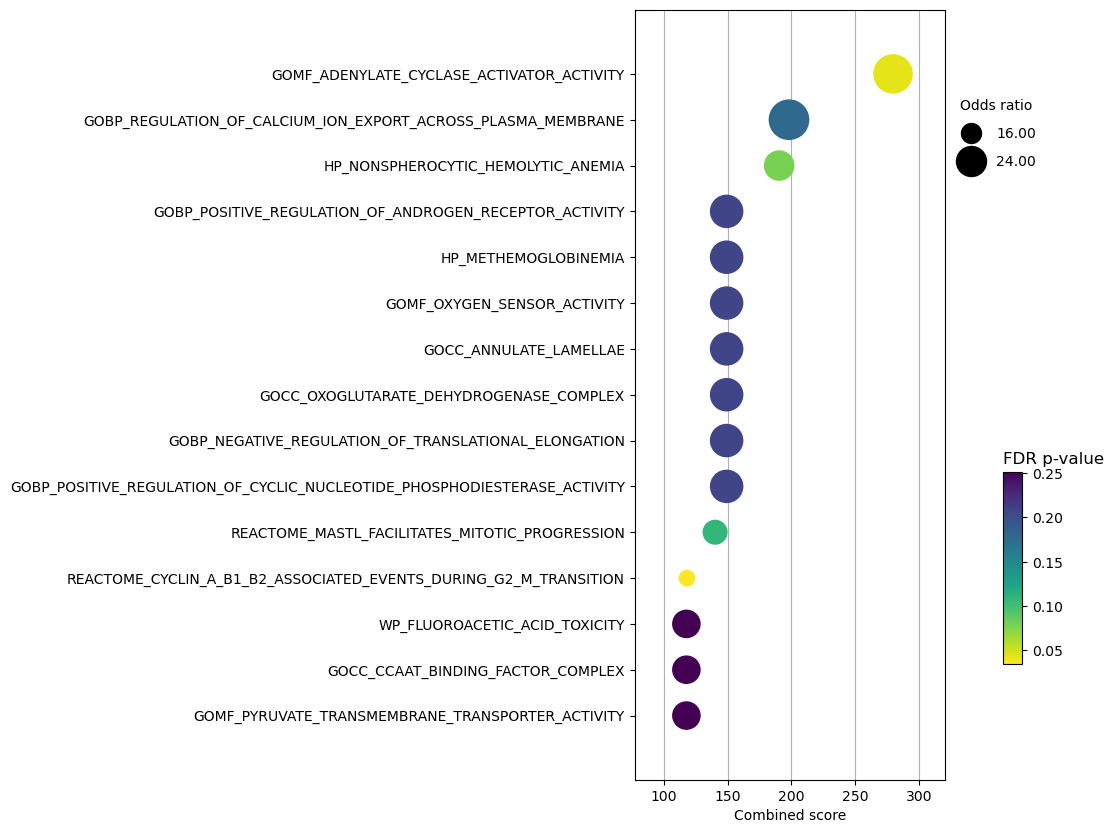

In [26]:
dc.plot_dotplot(
    enr_pvals.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=.15,
    figsize=(5, 10)
)

/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Top 10 ORA Results by Combined Score'}, xlabel='Combined Score', ylabel='Pathway'>)

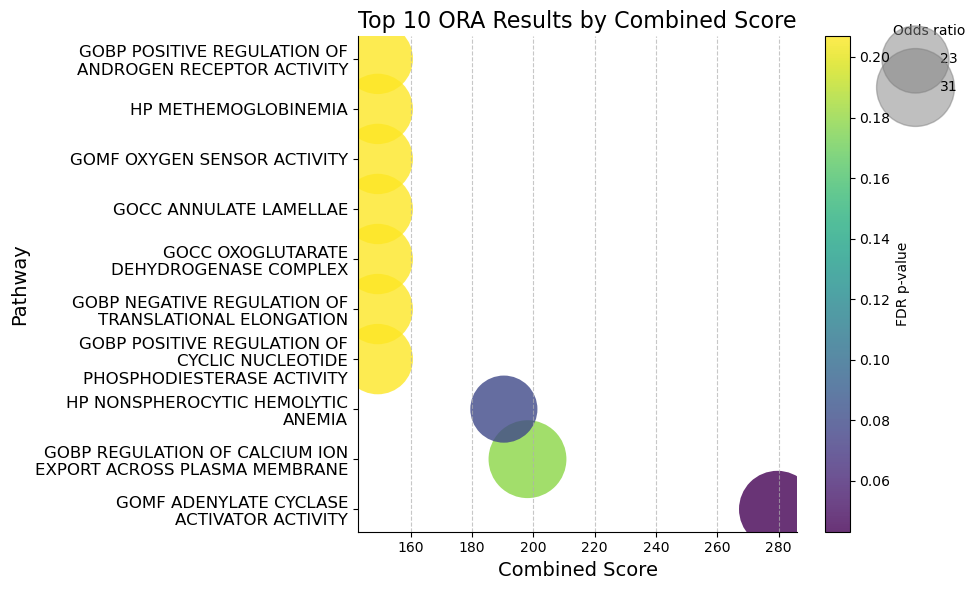

In [10]:
from plot_GSEA_ORA import *
plot_ora_results(enr_pvals)

/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


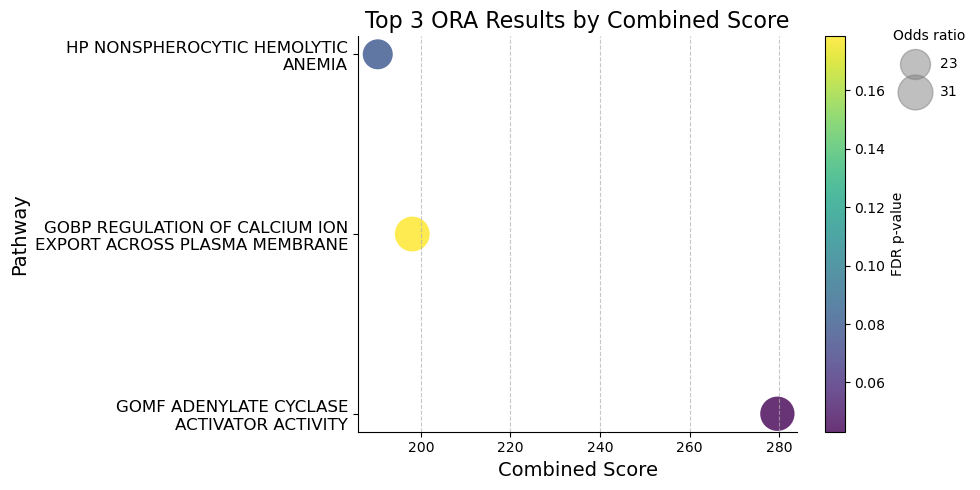

In [22]:
fig, ax = plot_ora_results(enr_pvals, top_n=3, figsize=(10, 5), scale_odds_ratio=20, 
                     fontsize_title=16, fontsize_subtitle=14, fontsize_text=12,
                     fdr_bar_size=[0.8, 0.15, 0.03, 0.5], bbox_to_anchor=(1.3, 1.05))

In [23]:
fig.savefig(f"results/{experiment}_{comparison}_ORA_bubble.png", bbox_inches='tight')


In [26]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}